# S-Curve Parameter Tuning Workflow

Manual, staged parameter tuning for the merged velocity manifold fitter. Vary one parameter at a time, inspect the metrics and plots, then fix that parameter before moving to the next stage.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "scripts").exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root))

from scripts.velocity_manifold_fitter import VelocityManifoldFitter

## Data

The S-curve is generated in embedded 3D space with Gaussian noise added directly to the embedding. The true velocity points along the S direction, not the vertical coordinate.

In [2]:
def normalize_rows(X, eps=1e-12):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)


def make_s_curve(n=450, sigma_embed=0.20, sigma_v=0.20, seed=11):
    rng = np.random.default_rng(seed)
    t = np.sort(3 * np.pi * (rng.uniform(size=n) - 0.5))
    y = 2.0 * rng.uniform(size=n)

    clean = np.empty((n, 3), dtype=float)
    clean[:, 0] = np.sin(t)
    clean[:, 1] = y
    clean[:, 2] = np.sign(t) * (np.cos(t) - 1.0)

    dt = np.c_[np.cos(t), np.zeros(n), -np.sign(t) * np.sin(t)]
    tangent = normalize_rows(dt)

    X = clean + rng.normal(scale=sigma_embed, size=clean.shape)
    W = tangent + rng.normal(scale=sigma_v, size=tangent.shape)
    return X, W, clean, tangent, t


X, W, X_clean, V_true, color = make_s_curve()

In [3]:
def project_to_s_curve(Z, n_grid=4096):
    t_grid = np.linspace(-1.5 * np.pi, 1.5 * np.pi, n_grid)
    curve_xz = np.c_[np.sin(t_grid), np.sign(t_grid) * (np.cos(t_grid) - 1.0)]
    tangent_grid = normalize_rows(np.c_[np.cos(t_grid), np.zeros_like(t_grid), -np.sign(t_grid) * np.sin(t_grid)])

    z_xz = Z[:, [0, 2]]
    best_dist2 = np.full(Z.shape[0], np.inf)
    best_idx = np.zeros(Z.shape[0], dtype=int)

    for start in range(0, n_grid, 512):
        stop = min(start + 512, n_grid)
        diff = z_xz[:, None, :] - curve_xz[None, start:stop, :]
        dist2 = np.sum(diff * diff, axis=2)
        local_idx = np.argmin(dist2, axis=1)
        local_best = dist2[np.arange(Z.shape[0]), local_idx]
        mask = local_best < best_dist2
        best_dist2[mask] = local_best[mask]
        best_idx[mask] = start + local_idx[mask]

    proj = np.zeros_like(Z)
    proj[:, 0] = curve_xz[best_idx, 0]
    proj[:, 1] = Z[:, 1]
    proj[:, 2] = curve_xz[best_idx, 1]
    return proj, tangent_grid[best_idx]


def velocity_cosine(Vhat, Vref):
    denom = np.linalg.norm(Vhat, axis=1) * np.linalg.norm(Vref, axis=1) + 1e-12
    return float(np.mean(np.sum(Vhat * Vref, axis=1) / denom))


def evaluate_result(name, Z, V):
    proj, V_proj = project_to_s_curve(Z)
    return {
        "name": name,
        "point_to_s_rmse": float(np.sqrt(np.mean(np.sum((Z - proj) ** 2, axis=1)))),
        "point_to_s_mean": float(np.mean(np.linalg.norm(Z - proj, axis=1))),
        "velocity_cosine": velocity_cosine(V, V_proj),
        "mean_displacement": float(np.mean(np.linalg.norm(Z - X, axis=1))),
    }

## Baseline And Staging

Edit `fixed_params` after each sweep. Once you choose a value, put it there and run the next sweep. Parameters in `fixed_params` override the baseline.

In [4]:
baseline = {
    # Important tuning parameters
    "d_mode": "adaptive",
    "adaptive_variance_threshold": 0.8,
    "adaptive_d_min": 2,
    "k": 25,
    "T": 5,
    "eta_g": 0.45,
    "theta": 0.1,
    # Defaults that should usually stay fixed
    "update_mode": "normal_only",
    "bandwidth_mode": "variable",
    # Lower-priority parameters
    "global_d": 2,
    "use_PCA": False,
    "PCA_dim": 30,
    "gamma": 2.0,
    "beta": 1.0,
    "kappa": 1.0,
    "cv": 0.0,
    "max_step_frac": 0.2,
    "h": 0.8,
    "recompute_neighbors": False,
    "use_abs_cos": False,
    "weight_use_abs_cos": True,
}

# Fill this in manually after each stage, for example:
# fixed_params = {"d_mode": "adaptive", "k": 25, "T": 5, "eta_g": 0.45, "theta": 0.1}
fixed_params = {}

important_sweeps = {
    "d_mode": ["adaptive", "global"],
    "adaptive_variance_threshold": [0.7, 0.8, 0.9],
    "adaptive_d_min": [1, 2, 3],
    "k": [10, 15, 25, 40, 60],
    "T": [5, 8, 10],
    "eta_g": [0.05, 0.1, 0.25, 0.45],
    "theta": [0.0, 0.05, 0.1, 0.25],
}

mode_checks = {
    "update_mode": ["normal_only", "original"],
    "bandwidth_mode": ["variable", "fixed"],
}

optional_sweeps = {
    "global_d": [1, 2, 3, 5],
    "use_PCA": [False, True],
    "PCA_dim": [10, 20, 30],
    "gamma": [1.0, 2.0, 4.0, 8.0, 16.0],
    "kappa": [0.0, 0.5, 1.0, 2.0, 4.0],
    "beta": [1.0, 2.0, 4.0],
    "cv": [0.0, 0.05, 0.1, 0.15, 0.25],
    "max_step_frac": [0.1, 0.2, 0.35, 0.5, 1.0],
    "recompute_neighbors": [False, True],
}

sweeps = {**important_sweeps, **mode_checks, **optional_sweeps}
recommended_order = list(important_sweeps.keys())
recommended_order


['d_mode',
 'adaptive_variance_threshold',
 'adaptive_d_min',
 'k',
 'T',
 'eta_g',
 'theta']

In [5]:
def split_params(params):
    fit_keys = {"update_mode", "velocity_mode", "blend_lambda"}
    init_params = {k: v for k, v in params.items() if k not in fit_keys}
    fit_params = {k: v for k, v in params.items() if k in fit_keys}
    fit_params.setdefault("update_mode", params.get("update_mode", "normal_only"))
    return init_params, fit_params


def run_config(label, overrides=None):
    params = baseline.copy()
    params.update(fixed_params)
    if overrides:
        params.update(overrides)

    init_params, fit_params = split_params(params)
    fitter = VelocityManifoldFitter(X, W, random_state=0, **init_params)
    out = fitter.fit(return_dict=True, **fit_params)
    metrics = evaluate_result(label, out["X"], out["V"])
    metrics.update({"changed_param": label})
    return params, out, metrics


def run_sweep(param_name, values=None):
    if values is None:
        values = sweeps[param_name]

    rows = []
    results = []
    for value in values:
        label = f"{param_name}={value}"
        params, out, metrics = run_config(label, {param_name: value})
        metrics["parameter"] = param_name
        metrics["value"] = value
        rows.append(metrics)
        results.append((label, out, params))

    return pd.DataFrame(rows), results

In [6]:
def set_equal_3d_limits(ax, Xref):
    mins = Xref.min(axis=0)
    maxs = Xref.max(axis=0)
    centers = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def draw_result_panel(ax, Z, V, title):
    step = max(1, X.shape[0] // 45)
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=color, cmap="viridis", s=10, alpha=0.85)
    ax.quiver(
        Z[::step, 0], Z[::step, 1], Z[::step, 2],
        V[::step, 0], V[::step, 1], V[::step, 2],
        length=0.45, normalize=True, color="black", linewidth=1.0, alpha=0.9,
    )
    ax.set_title(title, fontsize=10, pad=2)
    ax.view_init(elev=18, azim=-70)
    set_equal_3d_limits(ax, X_clean)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])


def plot_sweep_grid(results, title=None, ncols=3, include_input=True):
    panels = []
    if include_input:
        panels.append(("noisy input", {"X": X, "V": W}, None))
    panels.extend(results)

    nrows = int(np.ceil(len(panels) / ncols))
    fig = plt.figure(figsize=(4.2 * ncols, 4.35 * nrows), constrained_layout=False)

    for idx, (label, out, params) in enumerate(panels, start=1):
        ax = fig.add_subplot(nrows, ncols, idx, projection="3d")
        draw_result_panel(ax, out["X"], out["V"], label)

    for idx in range(len(panels) + 1, nrows * ncols + 1):
        ax = fig.add_subplot(nrows, ncols, idx, projection="3d")
        ax.set_axis_off()

    if title:
        fig.suptitle(title, y=0.985, fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.92])
    else:
        fig.tight_layout()
    return fig


## Reusable Manual Sweep Block

Copy the next two cells for each parameter. First set `current_param` and `candidate_values`, then inspect the table/grid. In the second cell, set `optimal_value` to your chosen candidate and run it to update `fixed_params`.


d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                  2.0
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
1,d_mode=global,0.134498,0.107193,0.959451,0.163431,d_mode=global,d_mode,global
0,d_mode=adaptive,0.136634,0.108319,0.958039,0.159806,d_mode=adaptive,d_mode,adaptive


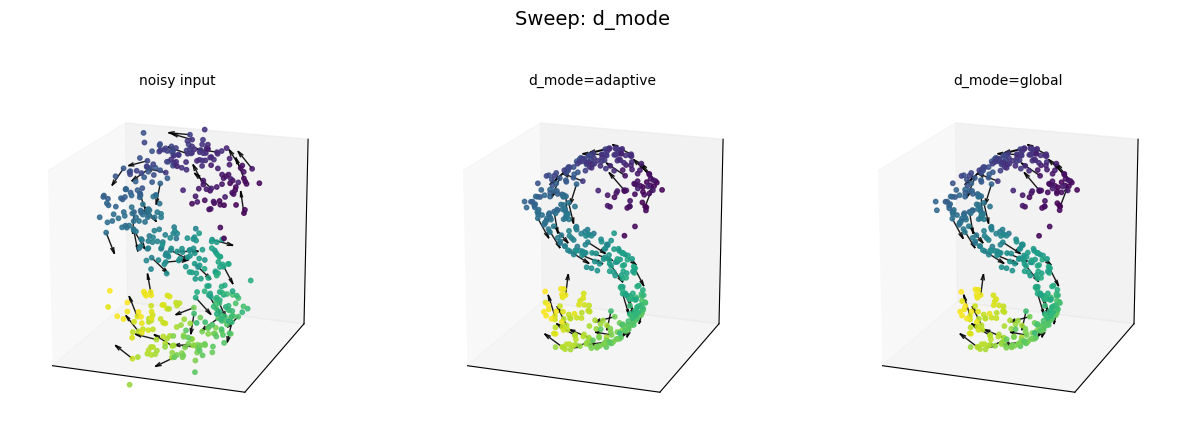

In [7]:
current_param = "d_mode"
candidate_values = ["adaptive", "global"]

# Examples for later copied blocks:
# current_param = "adaptive_variance_threshold"; candidate_values = [0.7, 0.8, 0.9]
# current_param = "adaptive_d_min"; candidate_values = [1, 2, 3]
# current_param = "k"; candidate_values = [10, 15, 25, 40, 60]
# current_param = "T"; candidate_values = [5, 8, 10]
# current_param = "eta_g"; candidate_values = [0.1, 0.25, 0.45, 0.7, 1.0]
# current_param = "theta"; candidate_values = [0.0, 0.1, 0.25, 0.5, 0.75]
# current_param = "global_d"; candidate_values = [1, 2, 3, 5]
# current_param = "bandwidth_mode"; candidate_values = ["variable", "fixed"]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [8]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = "adaptive"

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed d_mode = 'adaptive'


d_mode    adaptive
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                  2.0
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
0,bandwidth_mode=variable,0.136634,0.108319,0.958039,0.159806,bandwidth_mode=variable,bandwidth_mode,variable
1,bandwidth_mode=fixed,0.141676,0.113239,0.955483,0.161974,bandwidth_mode=fixed,bandwidth_mode,fixed


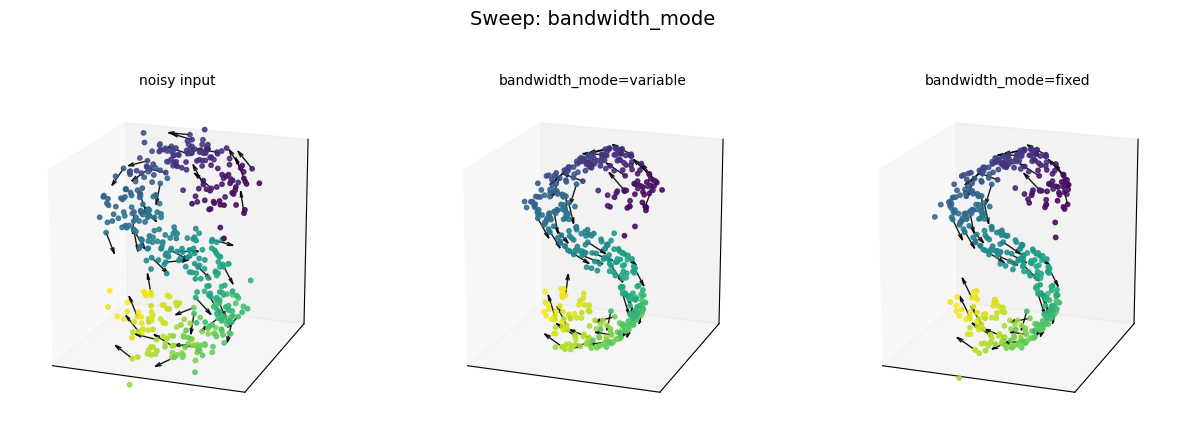

In [9]:
# Examples for later copied blocks:
current_param = "bandwidth_mode"; candidate_values = ["variable", "fixed"]
# current_param = "k"; candidate_values = [10, 15, 25, 40, 60]
# current_param = "eta_g"; candidate_values = [0.1, 0.25, 0.45, 0.7, 1.0]
# current_param = "theta"; candidate_values = [0.0, 0.1, 0.25, 0.5, 0.75]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [10]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = "variable"

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed bandwidth_mode = 'variable'


d_mode            adaptive
bandwidth_mode    variable
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                  2.0
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
1,k=15,0.129139,0.091993,0.942713,0.132694,k=15,k,15
2,k=25,0.136634,0.108319,0.958039,0.159806,k=25,k,25
0,k=10,0.145724,0.108726,0.896171,0.113152,k=10,k,10
3,k=40,0.192289,0.165524,0.953805,0.211270,k=40,k,40
4,k=60,0.264023,0.238710,0.935985,0.273754,k=60,k,60


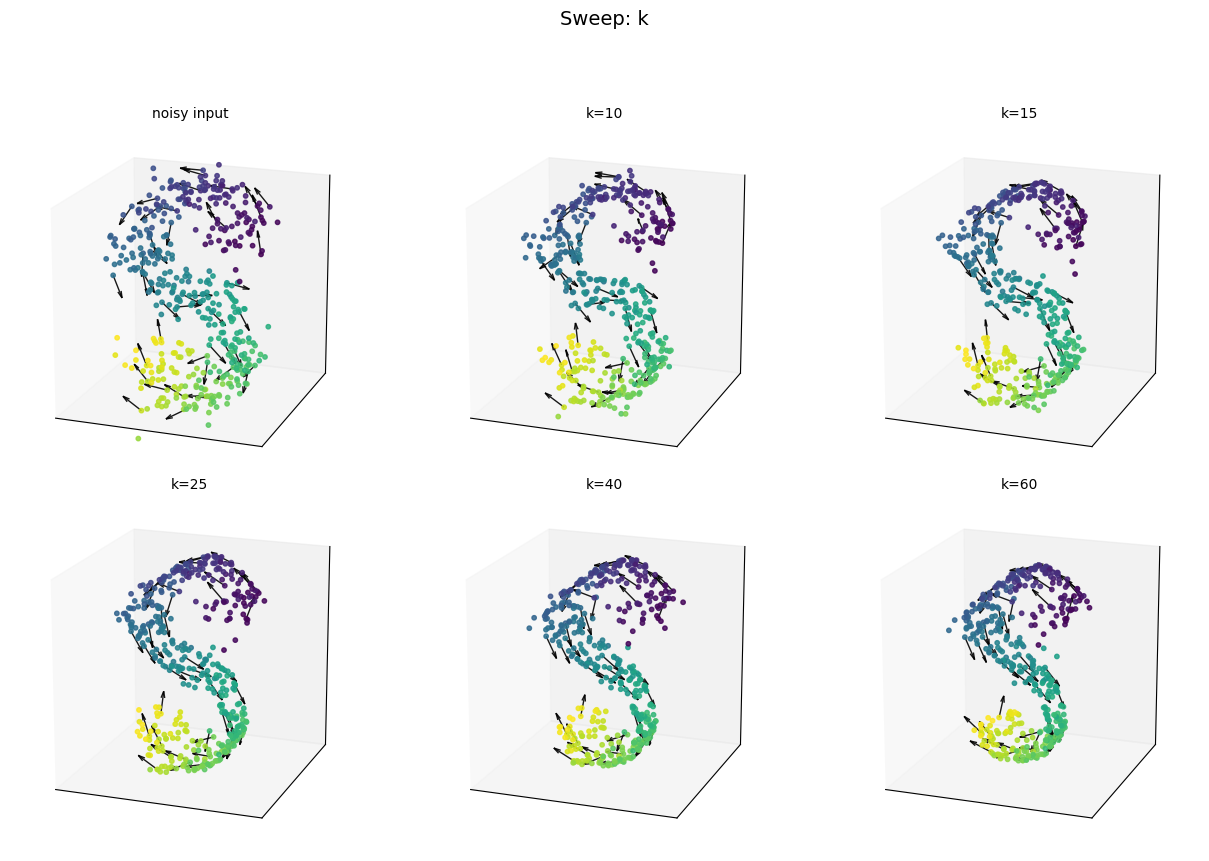

In [11]:
# Examples for later copied blocks:
current_param = "k"; candidate_values = [10, 15, 25, 40, 60]
# current_param = "eta_g"; candidate_values = [0.1, 0.25, 0.45, 0.7, 1.0]
# current_param = "theta"; candidate_values = [0.0, 0.1, 0.25, 0.5, 0.75]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [12]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 25

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed k = 25


d_mode            adaptive
bandwidth_mode    variable
k                       25
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                  2.0
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
1,eta_g=0.25,0.129920,0.095573,0.957177,0.112276,eta_g=0.25,eta_g,0.25
2,eta_g=0.45,0.136634,0.108319,0.958039,0.159806,eta_g=0.45,eta_g,0.45
0,eta_g=0.1,0.160908,0.124484,0.952040,0.053598,eta_g=0.1,eta_g,0.10
3,eta_g=0.7,0.165078,0.140746,0.956268,0.196503,eta_g=0.7,eta_g,0.70
4,eta_g=1.0,0.200654,0.176964,0.951938,0.229426,eta_g=1.0,eta_g,1.00


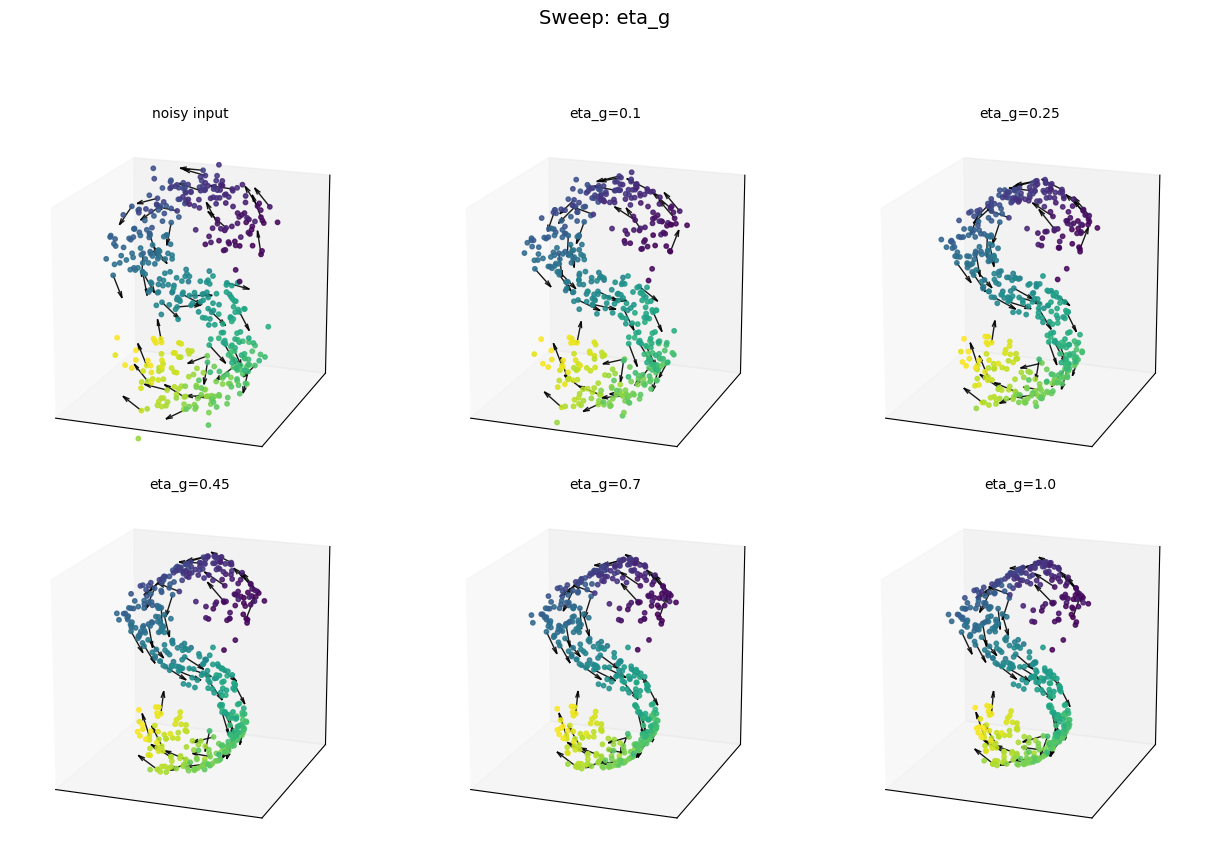

In [13]:
# Examples for later copied blocks:
current_param = "eta_g"; candidate_values = [0.1, 0.25, 0.45, 0.7, 1.0]
# current_param = "theta"; candidate_values = [0.0, 0.1, 0.25, 0.5, 0.75]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [14]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 0.45

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed eta_g = 0.45


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                  2.0
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
0,theta=0.0,0.130407,0.101914,0.963795,0.161189,theta=0.0,theta,0.00
3,theta=0.5,0.132776,0.098853,0.860426,0.166171,theta=0.5,theta,0.50
1,theta=0.1,0.136634,0.108319,0.958039,0.159806,theta=0.1,theta,0.10
2,theta=0.25,0.137987,0.107895,0.943682,0.164479,theta=0.25,theta,0.25
4,theta=0.75,0.294922,0.266662,0.671666,0.369875,theta=0.75,theta,0.75


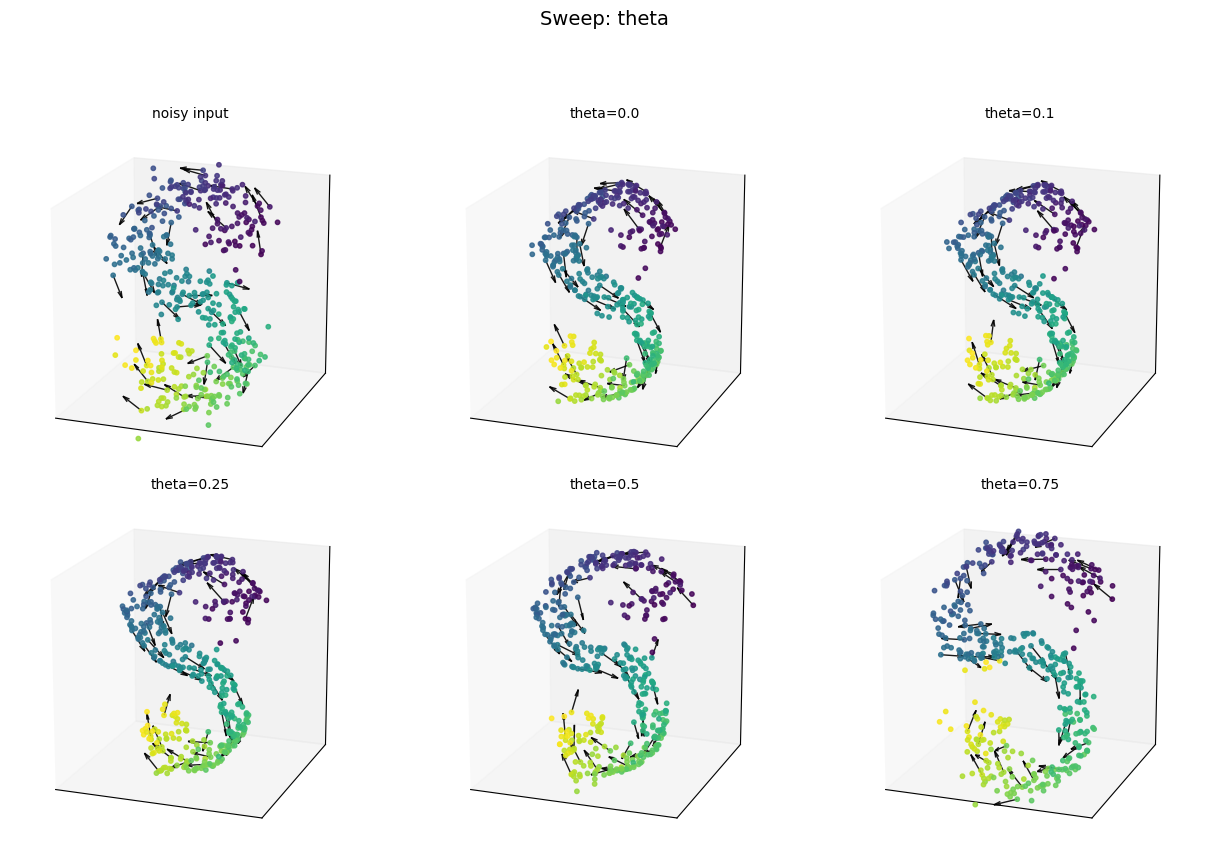

In [15]:
# Examples for later copied blocks:
current_param = "theta"; candidate_values = [0.0, 0.1, 0.25, 0.5, 0.75]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [16]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 0.1

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed theta = 0.1


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
theta                  0.1
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                  2.0
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
0,cv=0.0,0.136634,0.108319,0.958039,0.159806,cv=0.0,cv,0.00
1,cv=0.1,0.136634,0.108319,0.958039,0.159806,cv=0.1,cv,0.10
2,cv=0.25,0.136634,0.108319,0.958039,0.159806,cv=0.25,cv,0.25
3,cv=0.5,0.136634,0.108319,0.958039,0.159806,cv=0.5,cv,0.50
4,cv=0.75,0.136634,0.108319,0.958039,0.159806,cv=0.75,cv,0.75


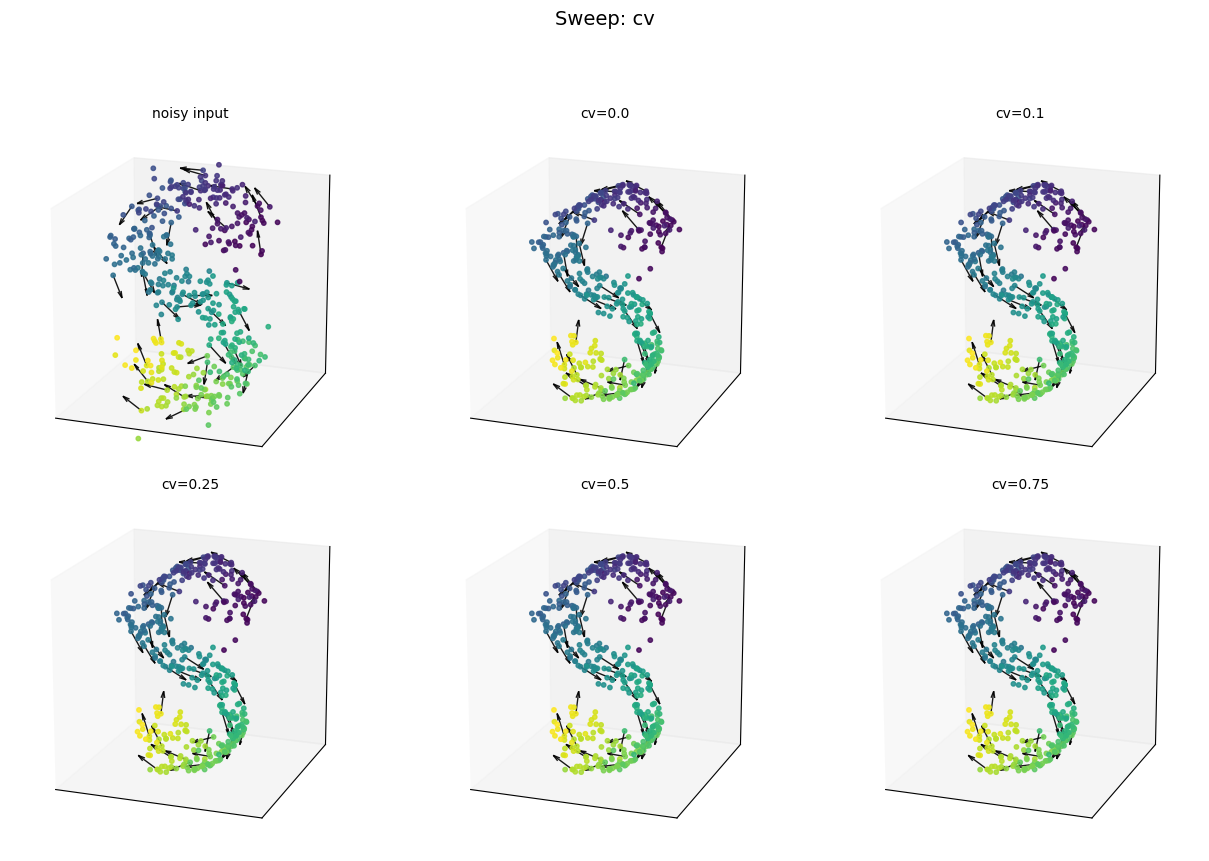

In [17]:
# Examples for later copied blocks:
current_param = "cv"; candidate_values = [0.0, 0.1, 0.25, 0.5, 0.75]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [18]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 0.

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed cv = 0.0


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
theta                  0.1
cv                     0.0
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                  2.0
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
0,gamma=1,0.135569,0.106819,0.961401,0.161823,gamma=1,gamma,1
1,gamma=2,0.136634,0.108319,0.958039,0.159806,gamma=2,gamma,2
2,gamma=4,0.138070,0.109424,0.955076,0.160616,gamma=4,gamma,4
3,gamma=8,0.140304,0.110903,0.953360,0.160980,gamma=8,gamma,8
4,gamma=16,0.140517,0.111274,0.951153,0.161769,gamma=16,gamma,16


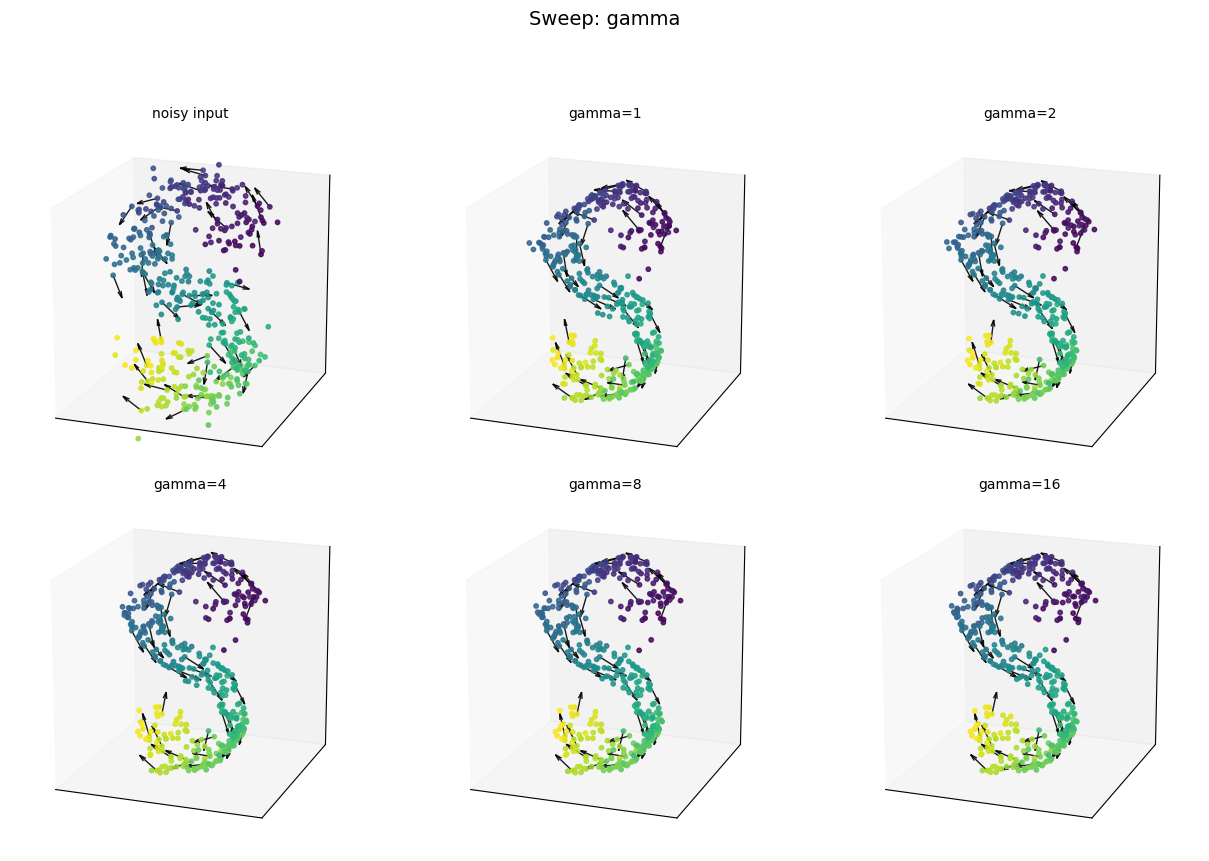

In [19]:
# Examples for later copied blocks:
current_param = "gamma"; candidate_values = [1, 2, 4, 8, 16]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [20]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 2

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed gamma = 2


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
theta                  0.1
cv                     0.0
gamma                    2
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                    2
beta                                   1.0
kappa                                  1.0
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
0,kappa=0.0,0.132072,0.103467,0.960178,0.162047,kappa=0.0,kappa,0.0
1,kappa=0.5,0.134582,0.106394,0.958790,0.161762,kappa=0.5,kappa,0.5
2,kappa=1.0,0.136634,0.108319,0.958039,0.159806,kappa=1.0,kappa,1.0
3,kappa=2.0,0.137335,0.109853,0.956215,0.158580,kappa=2.0,kappa,2.0
4,kappa=4.0,0.141358,0.111333,0.950212,0.149831,kappa=4.0,kappa,4.0


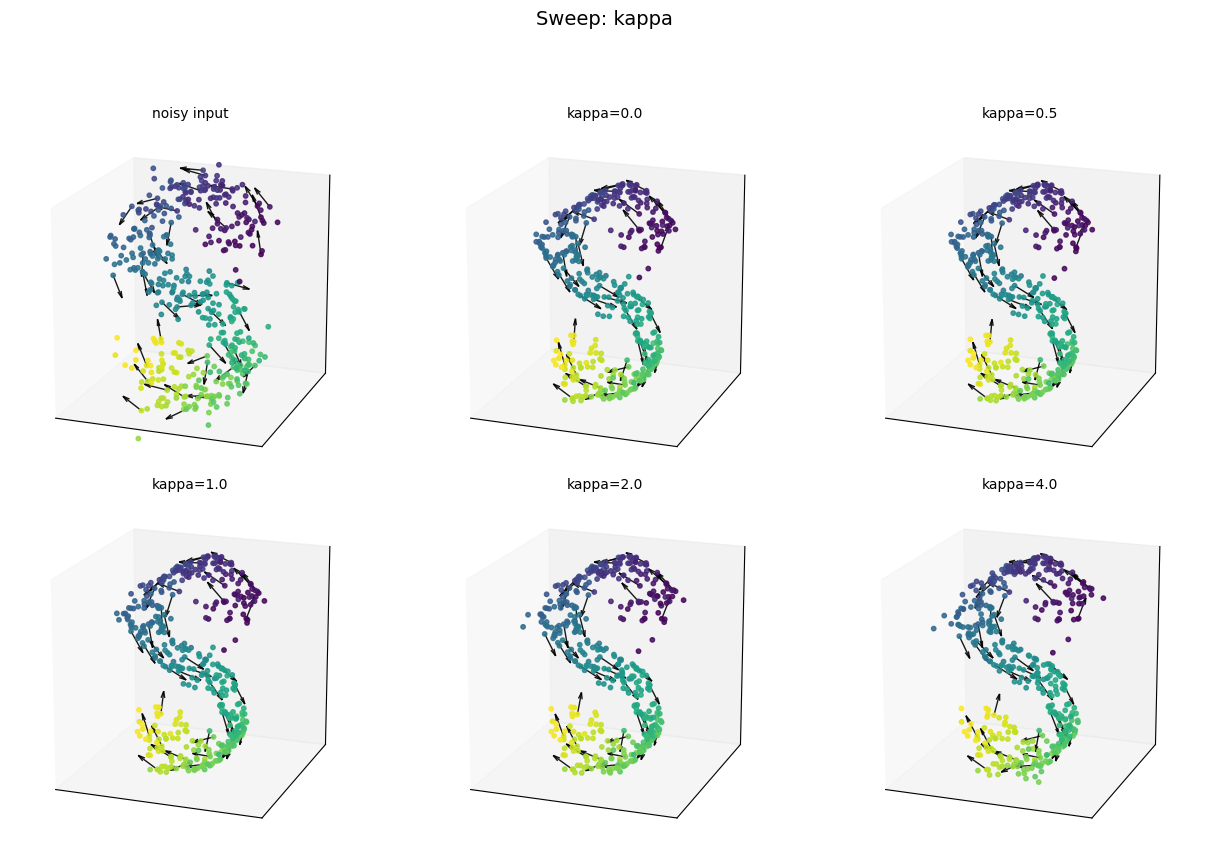

In [21]:
# Examples for later copied blocks:
current_param = "kappa"; candidate_values = [0.0, 0.5, 1.0, 2.0, 4.0]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [22]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 1

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed kappa = 1


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
theta                  0.1
cv                     0.0
gamma                    2
kappa                    1
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                    2
beta                                   1.0
kappa                                    1
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
1,beta=2,0.123317,0.091917,0.961136,0.145733,beta=2,beta,2
2,beta=4,0.124165,0.088278,0.950679,0.125731,beta=4,beta,4
0,beta=1,0.136634,0.108319,0.958039,0.159806,beta=1,beta,1


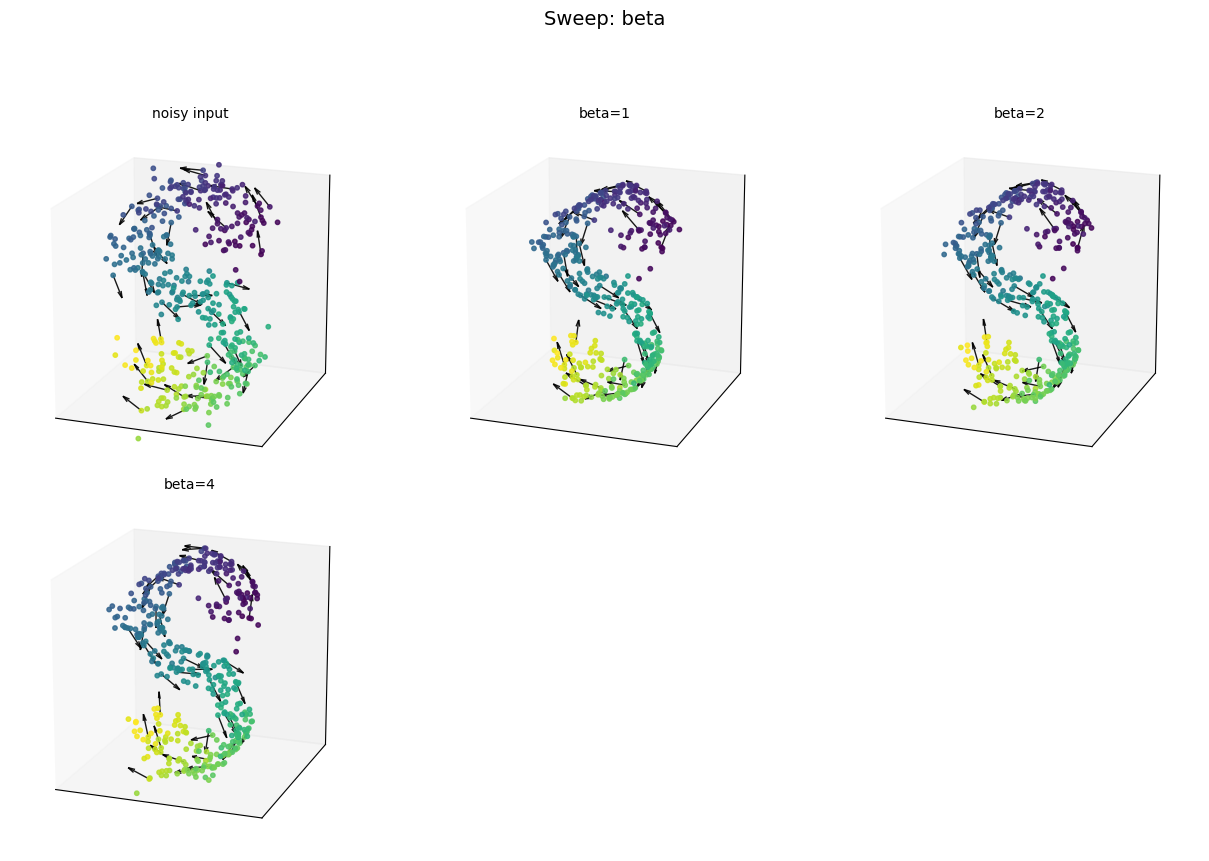

In [23]:
# Examples for later copied blocks:
current_param = "beta"; candidate_values = [1, 2, 4]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [24]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 1

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed beta = 1


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
theta                  0.1
cv                     0.0
gamma                    2
kappa                    1
beta                     1
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                    2
beta                                     1
kappa                                    1
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
1,T=5,0.136634,0.108319,0.958039,0.159806,T=5,T,5
0,T=1,0.161876,0.124963,0.953143,0.053918,T=1,T,1
2,T=10,0.202169,0.178546,0.950657,0.226246,T=10,T,10
3,T=20,0.338076,0.312405,0.924284,0.349170,T=20,T,20
4,T=50,0.581395,0.550098,0.799528,0.604085,T=50,T,50


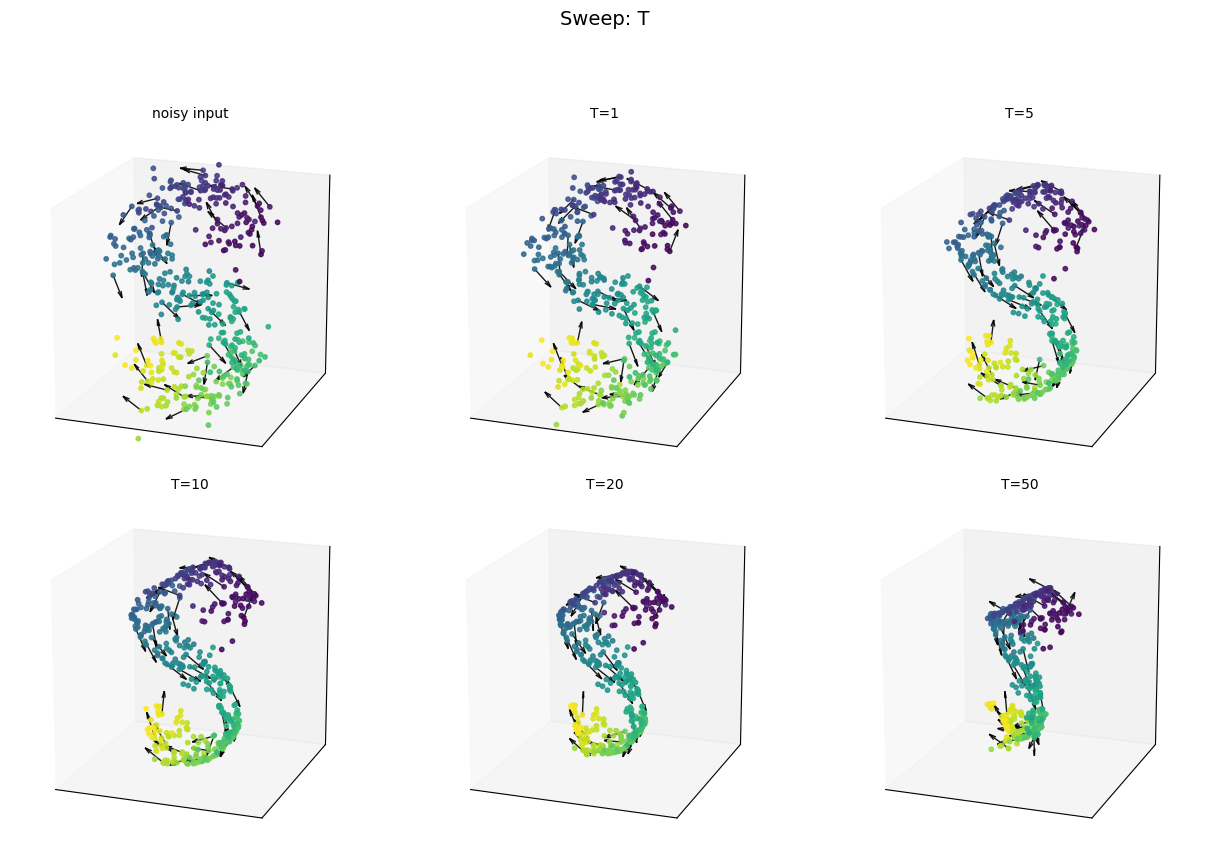

In [25]:
# Examples for later copied blocks:
current_param = "T"; candidate_values = [1, 5, 10, 20, 50]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [26]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 5

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed T = 5


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
theta                  0.1
cv                     0.0
gamma                    2
kappa                    1
beta                     1
T                        5
Name: fixed_params, dtype: object

d_mode                            adaptive
adaptive_variance_threshold            0.8
adaptive_d_min                           2
k                                       25
T                                        5
eta_g                                 0.45
theta                                  0.1
update_mode                    normal_only
bandwidth_mode                    variable
global_d                                 2
use_PCA                              False
PCA_dim                                 30
gamma                                    2
beta                                     1
kappa                                    1
cv                                     0.0
max_step_frac                          0.2
h                                      0.8
recompute_neighbors                  False
use_abs_cos                          False
weight_use_abs_cos                    True
Name: current baseline, dtype: object

,name,point_to_s_rmse,point_to_s_mean,velocity_cosine,mean_displacement,changed_param,parameter,value
0,max_step_frac=0.1,0.131201,0.101422,0.958749,0.149177,max_step_frac=0.1,max_step_frac,0.10
1,max_step_frac=0.2,0.136634,0.108319,0.958039,0.159806,max_step_frac=0.2,max_step_frac,0.20
2,max_step_frac=0.35,0.137310,0.109061,0.957279,0.161155,max_step_frac=0.35,max_step_frac,0.35
3,max_step_frac=0.5,0.137310,0.109061,0.957279,0.161155,max_step_frac=0.5,max_step_frac,0.50
4,max_step_frac=1.0,0.137310,0.109061,0.957279,0.161155,max_step_frac=1.0,max_step_frac,1.00


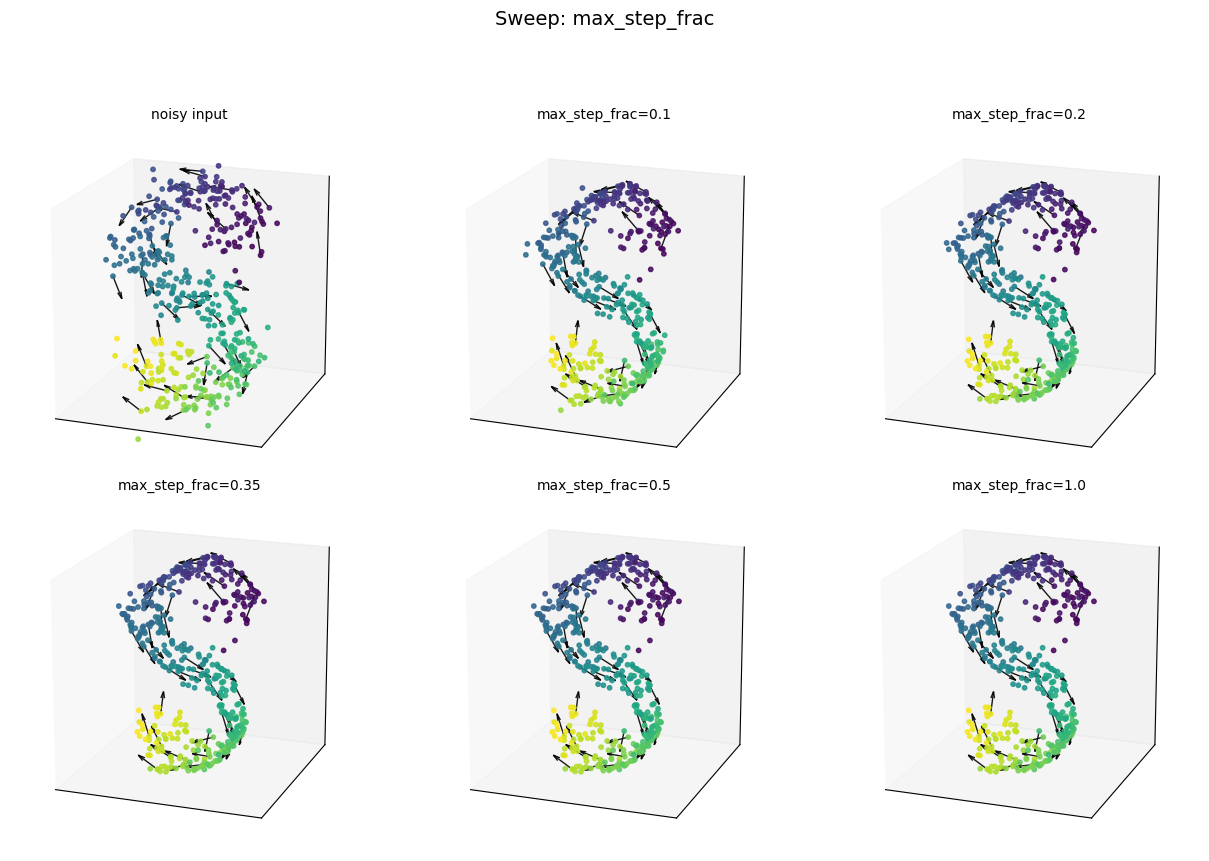

In [27]:
# Examples for later copied blocks:
current_param = "max_step_frac"; candidate_values = [0.1, 0.2, 0.35, 0.5, 1.0]

# Baseline used for this sweep after previous choices are applied.
display(pd.Series({**baseline, **fixed_params}, name="current baseline"))

df, results = run_sweep(current_param, candidate_values)
display(df.sort_values(["point_to_s_rmse", "velocity_cosine"], ascending=[True, False]))
plot_sweep_grid(results, title=f"Sweep: {current_param}", ncols=3)
plt.show()


In [28]:
# Set this to the candidate you pick from the table/grid above.
optimal_value = 0.2

fixed_params[current_param] = optimal_value
print(f"Fixed {current_param} = {optimal_value!r}")
display(pd.Series(fixed_params, name="fixed_params"))


Fixed max_step_frac = 0.2


d_mode            adaptive
bandwidth_mode    variable
k                       25
eta_g                 0.45
theta                  0.1
cv                     0.0
gamma                    2
kappa                    1
beta                     1
T                        5
max_step_frac          0.2
Name: fixed_params, dtype: object